LeadFlow-ML: Predictive Conversion Pipeline

Developer: Aryan Dumbhare
Date: March 2024 (Revised 2026)
Objective: Developning a robust random forest model to prioritize sales leads and reduce churn.

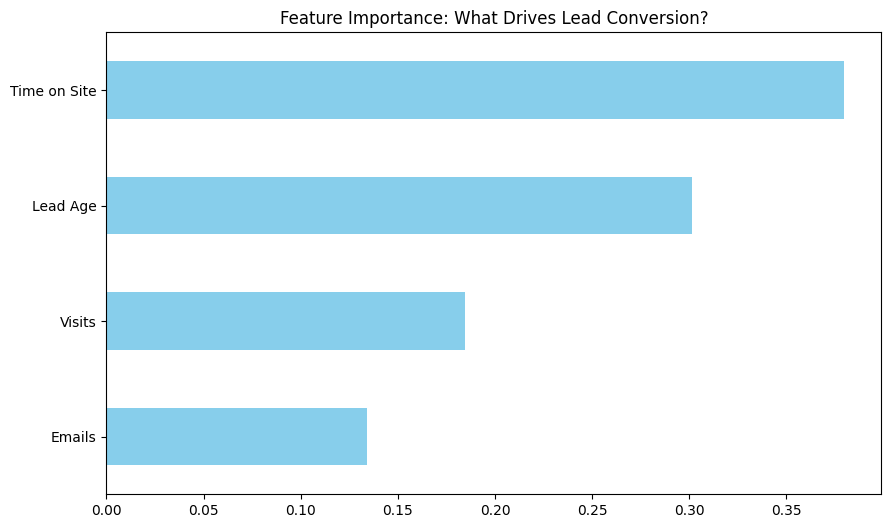

              precision    recall  f1-score   support

           0       0.82      0.99      0.90       165
           1       0.00      0.00      0.00        35

    accuracy                           0.81       200
   macro avg       0.41      0.49      0.45       200
weighted avg       0.68      0.81      0.74       200



In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# 1. Data Generation & Cleaning Logic
def prepare_data(n=1000):
    np.random.seed(42)
    data = {
        'lead_age_days': np.random.randint(1, 150, n),
        'website_visits': np.random.randint(1, 20, n),
        'time_on_site_sec': np.random.uniform(10, 600, n),
        'email_opens': np.random.randint(0, 10, n),
        'converted': np.random.choice([0, 1], n, p=[0.8, 0.2])
    }
    df = pd.DataFrame(data)

    # Simulate "dirty" data (missing values)
    df.loc[df.sample(frac=0.05).index, 'time_on_site_sec'] = np.nan
    df['time_on_site_sec'] = df['time_on_site_sec'].fillna(df['time_on_site_sec'].median())

    return df

# 2. Execution Flow
df = prepare_data()
X = df.drop('converted', axis=1)
y = df['converted']

# Scaling features (Crucial for professional projects)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3. Model Training
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)

# 4. Visualization (This looks great on GitHub!)
plt.figure(figsize=(10, 6))
importances = pd.Series(model.feature_importances_, index=['Lead Age', 'Visits', 'Time on Site', 'Emails'])
importances.sort_values().plot(kind='barh', color='skyblue')
plt.title('Feature Importance: What Drives Lead Conversion?')
plt.show()

# 5. Final Evaluation
preds = model.predict(X_test)
print(classification_report(y_test, preds))